<a href="https://colab.research.google.com/github/GH-Rumi/PCVK26_7_HelmiRR/blob/main/Week02_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum**

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
#Mengakses gambar dengan fungsi upload file

from google.colab import files
uploaded = files.upload()

Saving KTM.jpeg to KTM (1).jpeg


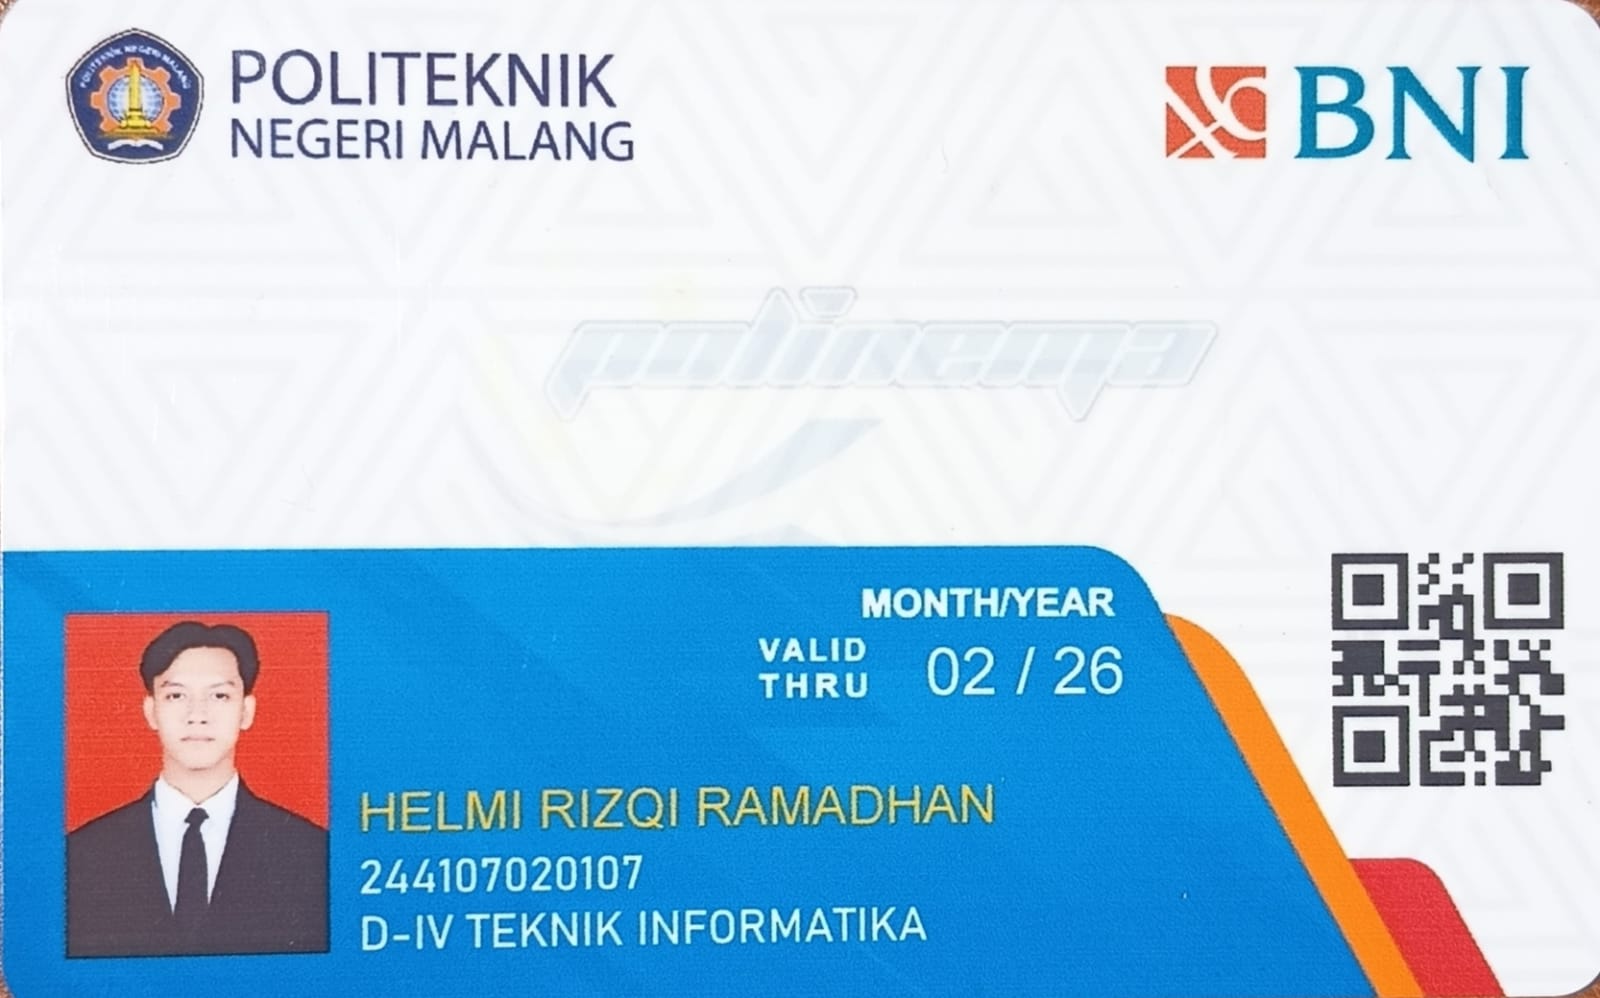

Resolusi gambar:  1600  x  998


In [14]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('KTM (1).jpeg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])

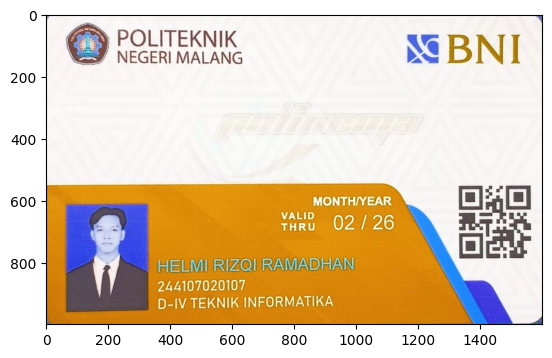

In [15]:
img = cv.imread('KTM (1).jpeg')
plt.imshow(img) #format warna BGR

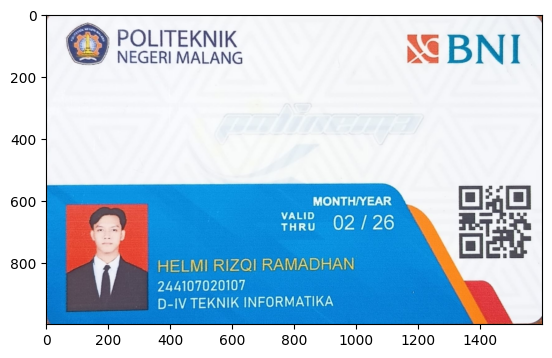

In [16]:
img = cv.imread('KTM (1).jpeg')
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB) #konversi channel BGR -> RGB
plt.imshow(img2)

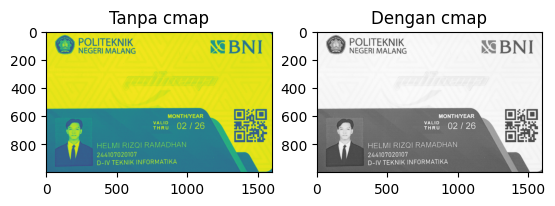

In [17]:
img_gray = cv.imread('KTM (1).jpeg', cv.IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1, 2, 1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

# Dengan cmap
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

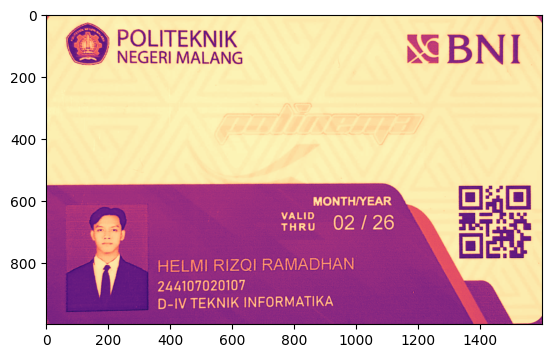

In [18]:
plt.imshow(img_gray, cmap='magma')

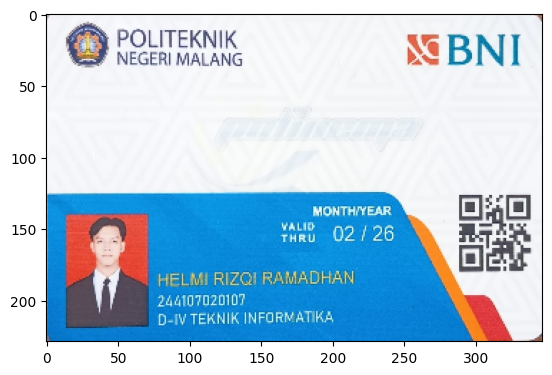

In [19]:
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_output = cv.resize(imgRGB, (347, 229))
plt.imshow(img_output)

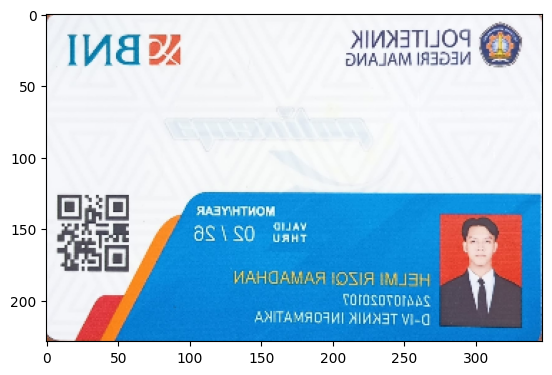

In [20]:
imgFlip=cv.flip(img_output, 1)
plt.imshow(imgFlip)

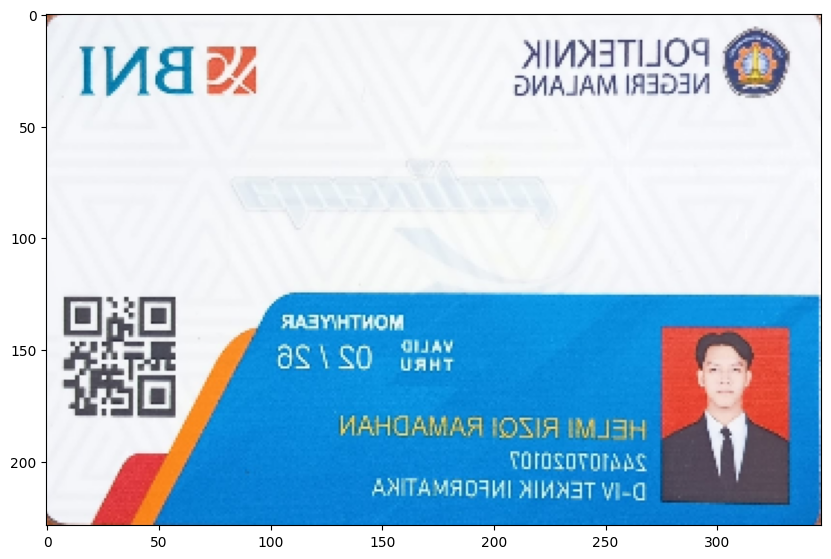

In [21]:
imgFlip=cv.flip(img_output, 1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

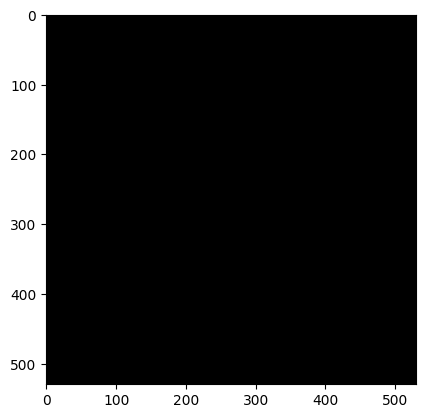

In [14]:
black_img = np.zeros(shape=(530,530,3), dtype=np.int16)
plt.imshow(black_img)

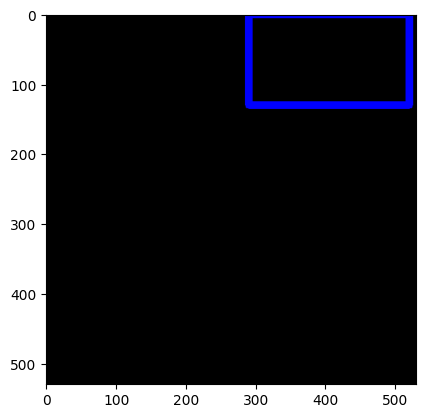

In [15]:
#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img, pt1=(290,0), pt2=(520,130), color=(0,0,255), thickness=10)
plt.imshow(black_img)

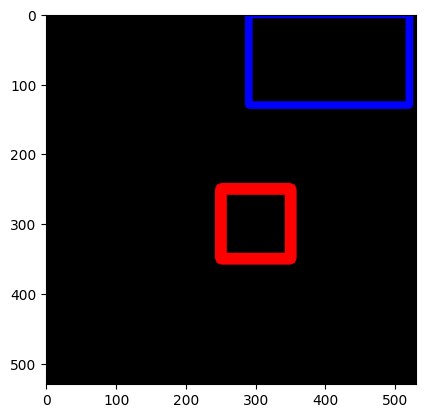

In [16]:
cv.rectangle(black_img, pt1=(250,250), pt2=(350,350), color=(255,0,0), thickness=15)
plt.imshow(black_img)

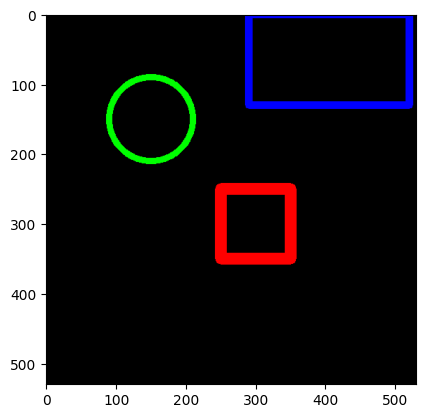

In [17]:
cv.circle(black_img, center=(150,150), radius=60, color=(0,255,0), thickness=8)
plt.imshow(black_img)

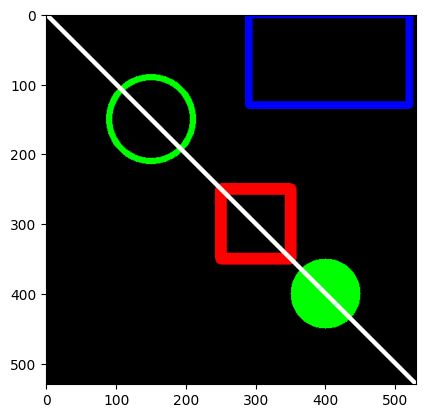

In [18]:
cv.circle(black_img, center=(400,400), radius=50, color=(0,255,0), thickness=-1)
cv.line(black_img, pt1=(0,0), pt2=(530,530), color=(255,255,255), thickness=5)
plt.imshow(black_img)

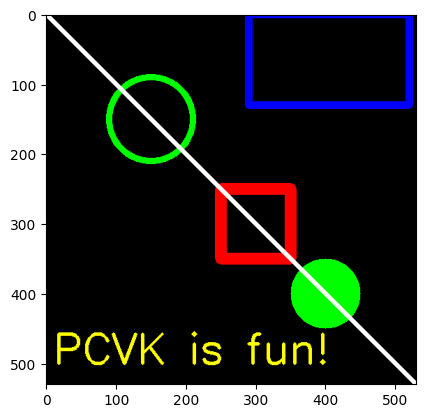

In [19]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!', org=(10,500), fontFace=font, fontScale=2,
           color=(255,255,0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

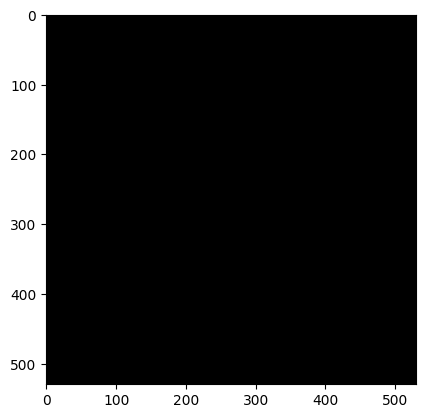

In [20]:
black_img2 = np.zeros(shape=(530,530,3), dtype=np.int32)
plt.imshow(black_img2)

In [21]:
vertices = np.array([[150,350], [250,250], [450,350], [250,450]], dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

In [22]:
pts = vertices.reshape((-1,1,2)) #nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channel yg mewakili R, G, dan B
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

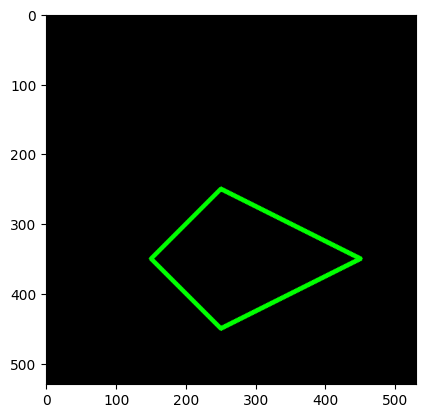

In [23]:
cv.polylines(black_img2, [pts], isClosed=True, color=(0,255,0), thickness=5)
plt.imshow(black_img2)

# **Pertanyaan Praktikum**

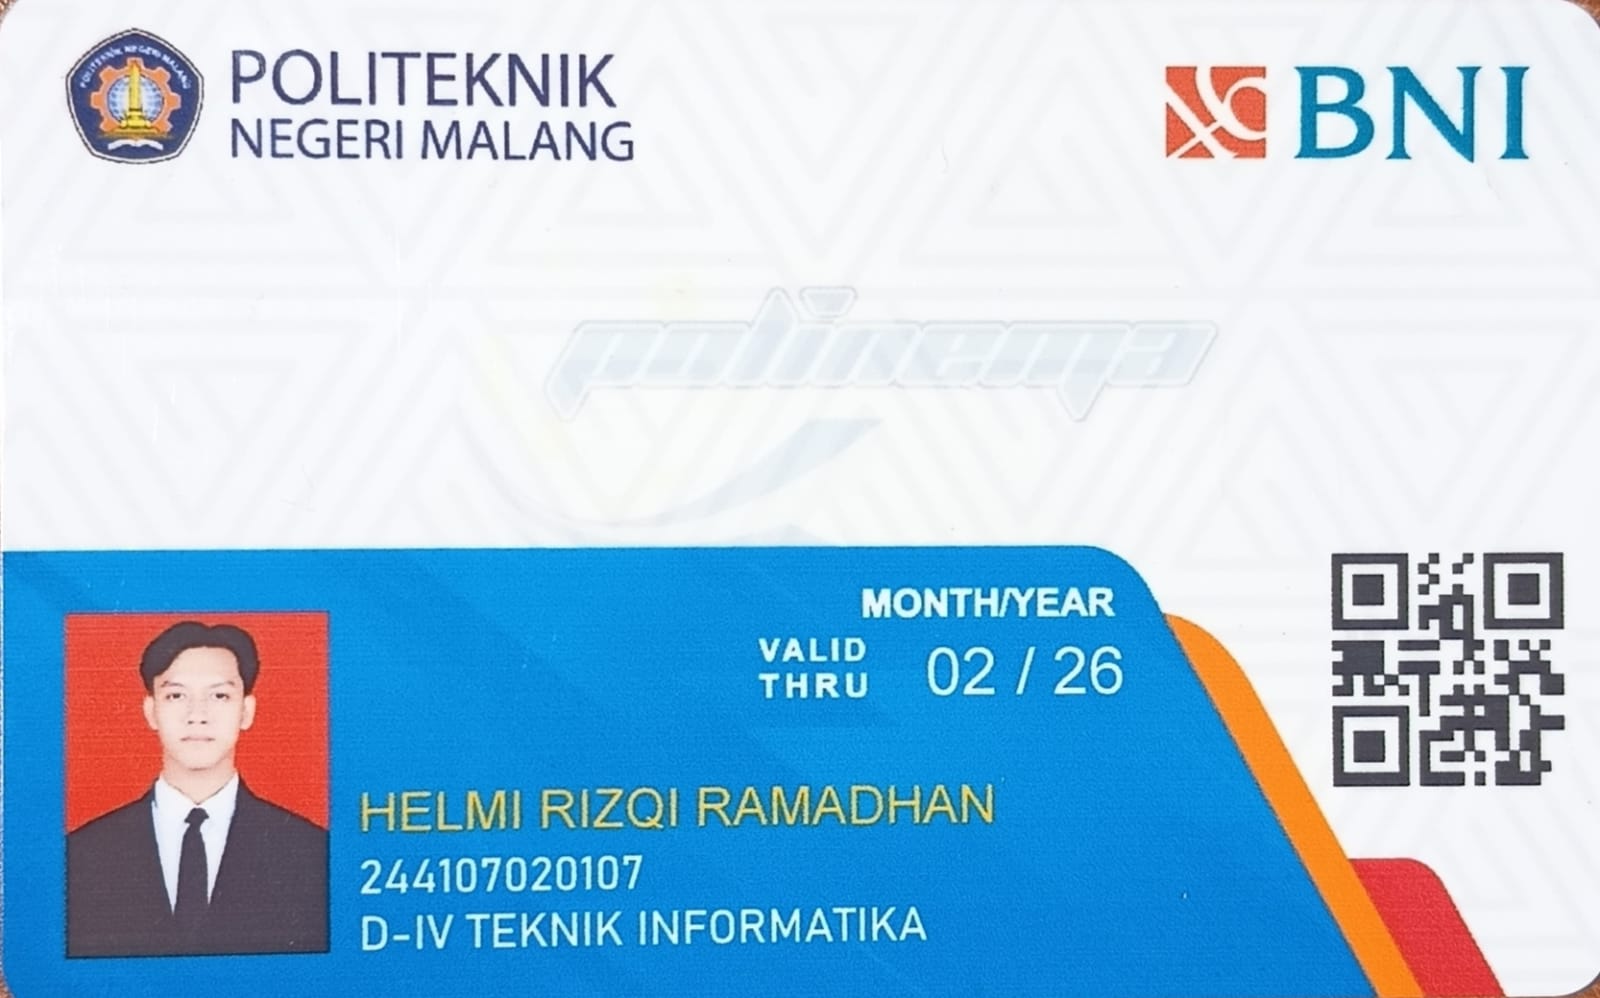

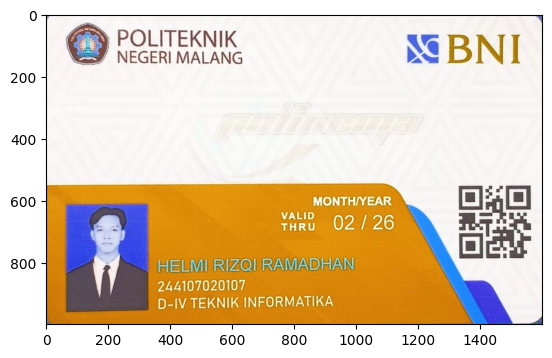

In [22]:
# Perbedaan menggunakan cv2_imshow dan plt.imshow

#cv2_imshow
img = cv.imread('KTM (1).jpeg')
cv2_imshow(img)

#plt.imshow
img = cv.imread('KTM (1).jpeg')
plt.imshow(img)

# 1. Perbedaan cv2_imshow() dan plt.imshow()
Hasilnya berbeda karena OpenCV secara bawaan membaca citra dalam format BGR, sedangkan Matplotlib menggunakan format RGB. Akibatnya, plt.imshow() menampilkan warna dengan channel Merah dan Biru yang tertukar

In [25]:
# perbandingan kanvas int16 dan int32

kanvas_16 = np.zeros((300, 400, 3), dtype=np.int16)
kanvas_32 = np.zeros((300, 400, 3), dtype=np.int32)
print("Min-Max 16 vs 32:", kanvas_16.min(), kanvas_16.max(), "|", kanvas_32.min(), kanvas_32.max())
print("nbytes 16 vs 32:", kanvas_16.nbytes, "vs", kanvas_32.nbytes)

Min-Max 16 vs 32: 0 0 | 0 0
nbytes 16 vs 32: 720000 vs 1440000


# 2. Perbandingan Kanvas int16 dan int32
Tampilannya sama (hitam pekat) karena rentang nilai pikselnya identik (0). Namun, ukuran memorinya berbeda karena int32 mengalokasikan memori 2x lebih besar (4 byte per channel) dibandingkan int16 (2 byte per channel)

# 3. Kegunaan cv2_imshow di Google Colab
cv2.imshow bawaan itu untuk membuka jendela baru di komputer lokal, karena itu sering terjadi error kalau dipakai di colab, jadi membutuhkan patches supaya gambarnya muncul langsung di sel

In [23]:
# perbandingan skimage dan OpenCV

image_skimage = io.imread('KTM (1).jpeg')
image_convert = cv.cvtColor(image_skimage, cv.COLOR_BGR2RGB)
print("Piksel Asli RGB:", image_skimage[0,0])
print("Piksel Konversi:", image_convert[0,0])

Piksel Asli RGB: [141  80  51]
Piksel Konversi: [ 51  80 141]


# 4. skimage vs Konversi OpenCV
Citra yang menampilkan warna sebenarnya adalah skimage, karena fungsi tersebut sejak awal sudah membaca gambar dalam format RGB. Jika citra tersebut dikenakan konversi cv2.COLOR_BGR2RGB, maka channel ke-1 (Merah) dan ke-3 (Biru) justru akan tertukar.

# 5. Perbedaan figsize dan Ukuran Citra
Nilai img.shape tidak ikut berubah.

Mengubah ukuran citra (cv2.resize): Memanipulasi jumlah matriks piksel sebenarnya di dalam memori

Mengubah ukuran tampilan (figsize): Hanya meregangkan gambar secara visual di antarmuka layar untuk pengamatan, tanpa mengubah data piksel aslinya.

# **Tugas Praktikum - Penerapan**

# 1. Menampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-Biru saja, dengan kanal yang tidak dipakai dinolkan

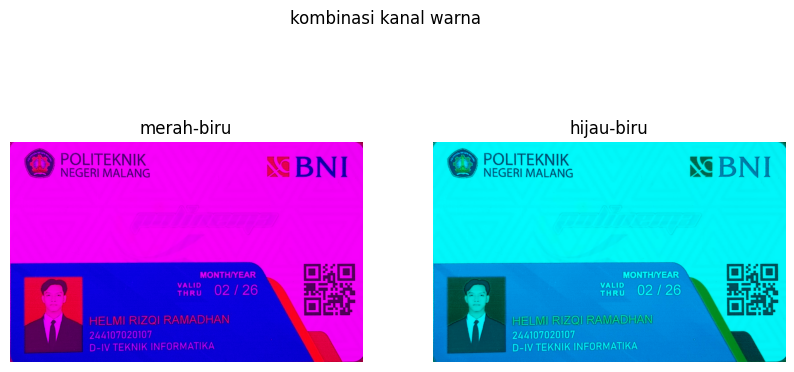

In [24]:
# baca gambar dan convert ke rgb dulu biar warnanya bener di plt
img = cv.imread('KTM (1).jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# merah-biru (kanal hijau atau index 1 dinolkan)
img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0

# hijau-biru (kanal merah atau index 0 dinolkan)
img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0

# bikin figure untuk menampilkan berdampingan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('kombinasi kanal warna')

ax1.imshow(img_rb)
ax1.set_title('merah-biru')
ax1.axis('off')

ax2.imshow(img_gb)
ax2.set_title('hijau-biru')
ax2.axis('off')

plt.show()

# 2. Menampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi label

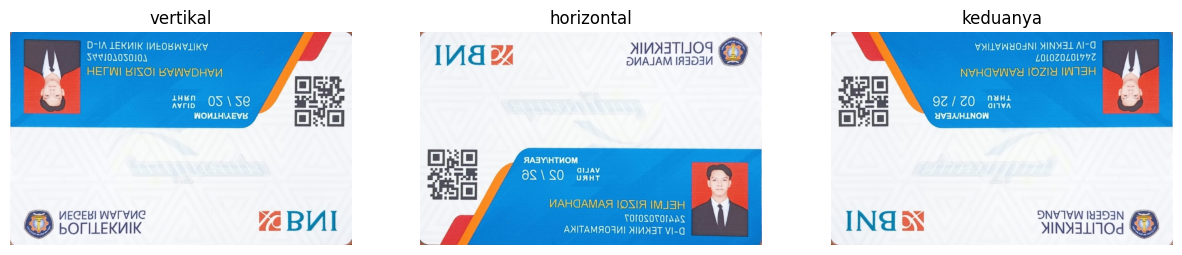

In [25]:
# flip 0 itu vertikal, 1 horizontal, -1 keduanya
flip_v = cv.flip(img_rgb, 0)
flip_h = cv.flip(img_rgb, 1)
flip_both = cv.flip(img_rgb, -1)

# bikin 1 figure dengan 3 subplot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.imshow(flip_v)
ax1.set_title('vertikal')
ax1.axis('off')

ax2.imshow(flip_h)
ax2.set_title('horizontal')
ax2.axis('off')

ax3.imshow(flip_both)
ax3.set_title('keduanya')
ax3.axis('off')

plt.show()

# 3. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah / badan dari foto aktivitas Anda sendiri lalu tambahkan teks berisi nama Anda

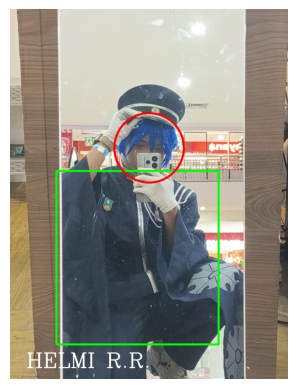

In [56]:
img_aktivitas = cv.imread('cosplay.jpeg')
img_draw = img_aktivitas.copy()

# kotak untuk badan warna hijau
cv.rectangle(img_draw, (200, 700), (900, 1450), (0, 255, 0), 8)

# lingkaran untuk wajah/topi warna merah
cv.circle(img_draw, (600, 600), 150, (0, 0, 255), 8)

# teks nama warna putih ditaruh agak bawah
font = cv.FONT_HERSHEY_COMPLEX
cv.putText(img_draw, 'HELMI R.R.', (70, 1550), font, 3, (255, 255, 255), 4)

img_draw_rgb = cv.cvtColor(img_draw, cv.COLOR_BGR2RGB)
plt.imshow(img_draw_rgb)
plt.axis('off')
plt.show()